# Preproceso e integración de datos

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Cargamos los conjuntos de datos

In [46]:
rfqs = pd.read_csv('../data/rfqs.csv')
volatility = pd.read_csv('../data/daily_volatility.csv')
reference = pd.read_csv('../data/underlyings_reference.csv')

rfqs.shape, volatility.shape, reference.shape

((25000, 17), (44744, 3), (14, 3))

Filtramos filas entrenables (executed = True), que son las que tienen valor en la variable objetivo avg_duration_months

In [47]:
rfqs_trainable = rfqs[rfqs["executed"] == True].copy()
rfqs_trainable["reference_date"] = rfqs_trainable["start_date"]
print(f"RFQs totales: {len(rfqs)}, con target: {len(rfqs_trainable)}")

RFQs totales: 25000, con target: 13796


Junte de datos e un único dataframe

In [48]:
# Normalización temporal
rfqs_trainable['requested_date'] = pd.to_datetime(rfqs_trainable['requested_date'])
volatility['date'] = pd.to_datetime(volatility['date'])

# Aplanado de underlyings
rfqs_exploded = rfqs_trainable.assign(underlying=rfqs_trainable['underlyings'].str.split('|', regex=False)).explode('underlying')
rfqs_exploded['underlying'] = rfqs_exploded['underlying'].str.strip()

# Cruce con la referencia de underlyings
rfqs_exploded = rfqs_exploded.merge(
    reference[['underlying', 'sector', 'structural_base_vol']],
    on='underlying',
    how='left'
)

# Cruce temporal de volatilidad por underlying usando el último dato disponible
rfqs_exploded = rfqs_exploded.sort_values(['requested_date', 'underlying'])
volatility_sorted = volatility.sort_values(['date', 'underlying'])

rfqs_exploded = pd.merge_asof(          # Cruzamos los dataframes por fecha y underlying
    rfqs_exploded,
    volatility_sorted[['underlying', 'date', 'realized_vol_63d']].rename(columns={'date': 'vol_date'}),
    left_on='requested_date',
    right_on='vol_date',
    by='underlying',
    direction='backward'
)

# Comprobación de valores nulos
print(f"Número de valores nulos: {rfqs_exploded.isnull().sum().sum()}")

Número de valores nulos: 0


Condensamos las características de los subyacentes de cada producto en una única fila a nivel de rfq

In [49]:
rfq_metrics = (
    rfqs_exploded.groupby('rfq_id', as_index=False)
    .agg(
        num_underlyings=('underlying', 'nunique'),
        vol_63d_min=('realized_vol_63d', 'min'),
        vol_63d_max=('realized_vol_63d', 'max'),
        vol_63d_mean=('realized_vol_63d', 'mean'),
        base_vol_min=('structural_base_vol', 'min'),
        base_vol_max=('structural_base_vol', 'max'),
        base_vol_mean=('structural_base_vol', 'mean'),
        sector_diversity=('sector', 'nunique')
    )
)

# Unimos con la tabla principal ya filtrada
rfqs_enriched = rfqs_trainable.merge(rfq_metrics, on='rfq_id', how='left')

# Comprobación de tipos de datos
rfqs_enriched.dtypes.value_counts()

object            10
float64           10
int64              4
datetime64[ns]     1
bool               1
Name: count, dtype: int64

Guardamos el dataframe enriquecido en un archivo parquet para su posterior uso

In [50]:
rfqs_enriched.to_parquet('../data/rfqs_preprocessed.parquet', index=False)
print(f"Dataset enriquecido guardado en '../data/rfqs_preprocessed.parquet'")

Dataset enriquecido guardado en '../data/rfqs_preprocessed.parquet'


# Mapa de correlación de las variables numéricas

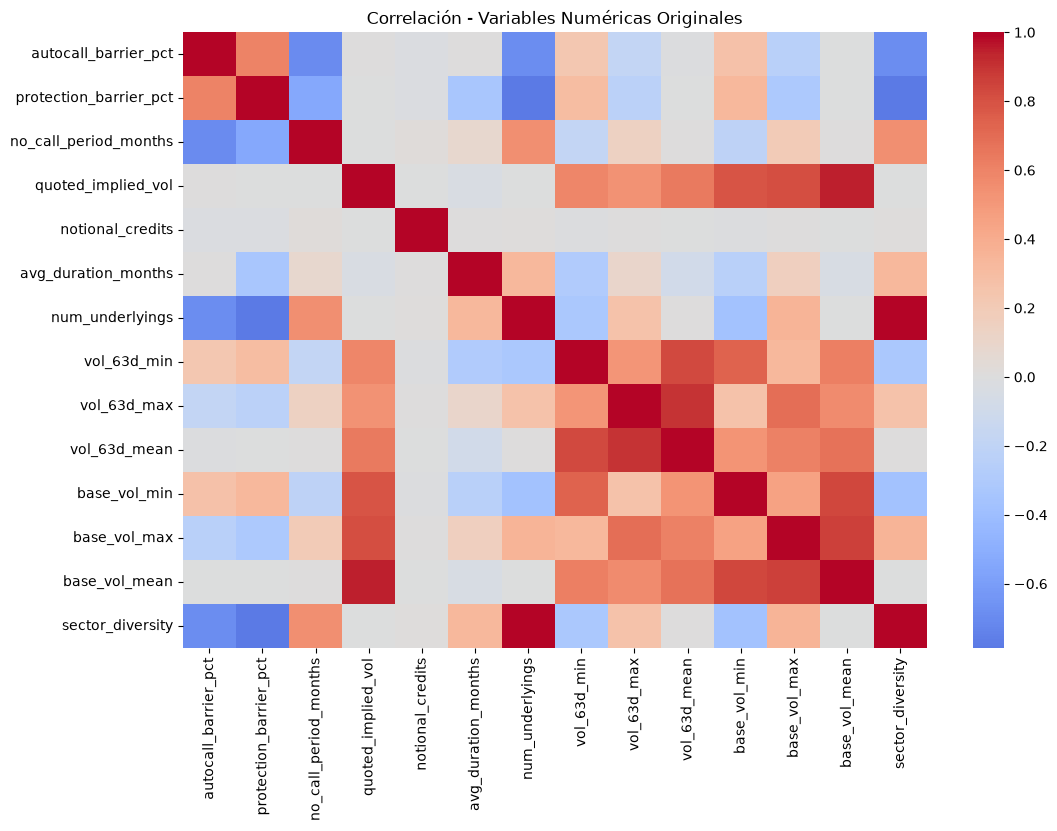

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlación solo sobre variables numéricas originales
numeric_df = rfqs_enriched.select_dtypes(include=['number']).copy()

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlación - Variables Numéricas Originales')
plt.show()

Observamos que hay variables muy correlacionadas tanto positiva como negativamente